# VGG16 — setup, splits, datasets (224×224) -- 1

In [1]:
import os, random, numpy as np, pandas as pd
import tensorflow as tf
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications.vgg16 import preprocess_input

In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

In [3]:
# ---- load metadata prepared in EDA ----
meta = pd.read_parquet("data/processed/meta_ready.parquet")
print("Loaded:", meta.shape)
print(meta.head())

Loaded: (10015, 6)
       image_id                                               path   dx  \
0  ISIC_0027419  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   
1  ISIC_0025030  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   
2  ISIC_0026769  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   
3  ISIC_0025661  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   
4  ISIC_0031633  /Users/rajdeeproy/UMBC/Resume_project/Skin-Les...  bkl   

                       cell_type  cell_type_idx  binary_label  
0  Benign keratosis-like lesions              2             0  
1  Benign keratosis-like lesions              2             0  
2  Benign keratosis-like lesions              2             0  
3  Benign keratosis-like lesions              2             0  
4  Benign keratosis-like lesions              2             0  


In [5]:
# ---- make sure we have a numeric class index ----
if "cell_type_idx" not in meta.columns:
    classes = sorted(meta["cell_type"].unique())
    class_to_idx = {c:i for i,c in enumerate(classes)}
    meta["cell_type_idx"] = meta["cell_type"].map(class_to_idx).astype(int)

NUM_CLASSES = meta["cell_type_idx"].nunique()
print("Classes:", NUM_CLASSES)

Classes: 7


In [6]:
# stratified split (train/val/test)
y = meta["cell_type_idx"].to_numpy()

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=SEED)
trainval_idx, test_idx = next(sss1.split(meta, y))

sss2 = StratifiedShuffleSplit(n_splits=1, test_size=0.20, random_state=SEED)  # 20% of 90% = 18%
train_idx, val_idx = next(sss2.split(meta.iloc[trainval_idx], y[trainval_idx]))

train_ids = meta.index.values[trainval_idx][train_idx]
val_ids   = meta.index.values[trainval_idx][val_idx]
test_ids  = meta.index.values[test_idx]

meta["split"] = "train"
meta.loc[val_ids, "split"] = "val"
meta.loc[test_ids, "split"] = "test"
print(meta["split"].value_counts())

split
train    7210
val      1803
test     1002
Name: count, dtype: int64


In [7]:
# ---- tf.data pipeline for VGG16 (224x224) ----
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = (224, 224)
BATCH_SIZE = 32  # smaller batch is safer for 224x224

In [8]:
def make_dataset(df, training=True):
    paths  = df["path"].to_list()
    labels = df["cell_type_idx"].to_numpy().astype("int32")
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def _load(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        img = tf.cast(img, tf.float32)
        # VGG16 expects BGR + mean subtraction; keras preprocess_input handles this
        img = preprocess_input(img)  # from keras.applications.vgg16 (works on float32 [0..255] or [0..1])
        if training:
            img = tf.image.random_flip_left_right(img)
            img = tf.image.random_flip_up_down(img)
            img = tf.image.random_contrast(img, 0.9, 1.1)
        label = tf.one_hot(label, depth=NUM_CLASSES)
        return img, label

    if training:
        ds = ds.shuffle(4096, seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(_load, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

In [9]:
train_ds = make_dataset(meta[meta["split"]=="train"], training=True)
val_ds   = make_dataset(meta[meta["split"]=="val"],   training=False)
test_ds  = make_dataset(meta[meta["split"]=="test"],  training=False)

2025-08-24 17:51:34.913501: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M3 Pro
2025-08-24 17:51:34.913574: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 18.00 GB
2025-08-24 17:51:34.913590: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 6.00 GB
2025-08-24 17:51:34.913626: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-08-24 17:51:34.913649: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [10]:
xb, yb = next(iter(train_ds))
print("Train batch shapes:", xb.shape, yb.shape)

Train batch shapes: (32, 224, 224, 3) (32, 7)


In [11]:
# ---- class weights (to counter imbalance) ----
y_train_idx = meta.loc[meta["split"]=="train", "cell_type_idx"].to_numpy()
classes_arr = np.arange(NUM_CLASSES)
weights_arr = compute_class_weight(class_weight="balanced", classes=classes_arr, y=y_train_idx)
CLASS_WEIGHTS = {int(c): float(w) for c, w in zip(classes_arr, weights_arr)}

print("Class weights:")
idx_to_class = (
    meta[["cell_type_idx","cell_type"]]
    .drop_duplicates()
    .sort_values("cell_type_idx")
    .set_index("cell_type_idx")["cell_type"]
    .to_dict()
)
for i, w in CLASS_WEIGHTS.items():
    print(f"  {i} ({idx_to_class[i]}): {w:.3f}")

Class weights:
  0 (Actinic keratoses): 4.383
  1 (Basal cell carcinoma): 2.784
  2 (Benign keratosis-like lesions): 1.302
  3 (Dermatofibroma): 12.410
  4 (Melanocytic nevi): 0.213
  5 (Melanoma): 1.284
  6 (Vascular lesions): 10.098


# VGG16 — model (freeze → train head) then (unfreeze top block → fine‑tune) -- 2

#### Build VGG16 + train head (base frozen ~3 epochs)

In [12]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16

In [13]:
def build_vgg16_head(num_classes=NUM_CLASSES, input_shape=(224,224,3)):
    base = VGG16(include_top=False, weights="imagenet", input_shape=input_shape)
    base.trainable = False   # freeze all layers for Stage A

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)           # important when base is frozen
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs, name="VGG16_finetune")
    return model, base


In [14]:
model, base = build_vgg16_head()
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "VGG16_finetune"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,980,935 (57.15 MB)

 Trainable params: 266,247 (1.02 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [15]:
# compile
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [16]:
# callbacks
os.makedirs("checkpoints", exist_ok=True)
ckpt_a = "checkpoints/vgg16_stageA.keras"
callbacks_a = [
    keras.callbacks.ModelCheckpoint(ckpt_a, monitor="val_loss", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
]

In [17]:
# train head briefly (feature extraction warm‑up)
hist_a = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=3,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_a
)

Epoch 1/3


2025-08-24 17:56:31.359243: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


226/226 ━━━━━━━━━━━━━━━━━━━━ 57s 242ms/step - accuracy: 0.3420 - loss: 5.5737 - val_accuracy: 0.5746 - val_loss: 1.9657 - learning_rate: 0.0010
Epoch 2/3
226/226 ━━━━━━━━━━━━━━━━━━━━ 54s 239ms/step - accuracy: 0.4007 - loss: 4.6124 - val_accuracy: 0.6267 - val_loss: 1.6699 - learning_rate: 0.0010
Epoch 3/3
226/226 ━━━━━━━━━━━━━━━━━━━━ 54s 241ms/step - accuracy: 0.4488 - loss: 4.0352 - val_accuracy: 0.5668 - val_loss: 2.1162 - learning_rate: 0.0010


#### Unfreeze block5 and fine‑tune (~20 epochs, smaller LR)

In [18]:
# Restore best Stage‑A weights (from val_loss)
model.load_weights("checkpoints/vgg16_stageA.keras")

In [19]:
# Unfreeze only block5_* layers
for layer in base.layers:
    layer.trainable = layer.name.startswith("block5")

In [20]:
# Re‑compile with a smaller LR for fine‑tuning
model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
ckpt_b = "checkpoints/vgg16_stageB.keras"
callbacks_b = [
    keras.callbacks.ModelCheckpoint(ckpt_b, monitor="val_loss", save_best_only=True),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
]

In [22]:
hist_b = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks_b
)

Epoch 1/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 67s 289ms/step - accuracy: 0.4331 - loss: 1.8015 - val_accuracy: 0.3905 - val_loss: 1.5127 - learning_rate: 1.0000e-04
Epoch 2/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 64s 285ms/step - accuracy: 0.4867 - loss: 1.4368 - val_accuracy: 0.3056 - val_loss: 2.3833 - learning_rate: 1.0000e-04
Epoch 3/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 65s 286ms/step - accuracy: 0.5208 - loss: 1.3370 - val_accuracy: 0.6251 - val_loss: 0.9653 - learning_rate: 1.0000e-04
Epoch 4/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 65s 289ms/step - accuracy: 0.5800 - loss: 1.1609 - val_accuracy: 0.6883 - val_loss: 0.9765 - learning_rate: 1.0000e-04
Epoch 5/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 65s 287ms/step - accuracy: 0.6028 - loss: 1.1321 - val_accuracy: 0.6545 - val_loss: 1.0645 - learning_rate: 1.0000e-04
Epoch 6/20
226/226 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.6823 - loss: 1.0299
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
226/226 ━━━━━━━━━━━━━━━━━━━━ 65s 286ms/st

#### Evaluation

In [24]:
# Load best weights from Stage B (if not already the current in-memory weights)
model.load_weights("checkpoints/vgg16_stageB.keras")

# 1) Quick test metrics
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"VGG16 Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

# 2) Full classification report + confusion matrix
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns, matplotlib.pyplot as plt

VGG16 Test loss: 0.9834  |  Test accuracy: 0.6208


In [25]:
# Gather predictions
y_true, y_pred = [], []
for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)
    y_pred.append(np.argmax(probs, axis=1))
    y_true.append(np.argmax(yb.numpy(), axis=1))
y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

# Human-readable class names
idx_to_class = (
    meta[["cell_type_idx","cell_type"]]
    .drop_duplicates()
    .sort_values("cell_type_idx")
    .set_index("cell_type_idx")["cell_type"]
    .to_dict()
)
names = [idx_to_class[i] for i in range(len(idx_to_class))]

2025-08-24 18:14:11.431531: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence



Classification report (VGG16):
                               precision    recall  f1-score   support

            Actinic keratoses      0.178     0.788     0.291        33
         Basal cell carcinoma      0.337     0.569     0.423        51
Benign keratosis-like lesions      0.528     0.173     0.260       110
               Dermatofibroma      0.170     0.667     0.271        12
             Melanocytic nevi      0.926     0.711     0.804       671
                     Melanoma      0.331     0.477     0.391       111
             Vascular lesions      0.833     0.714     0.769        14

                     accuracy                          0.621      1002
                    macro avg      0.472     0.586     0.459      1002
                 weighted avg      0.752     0.621     0.656      1002



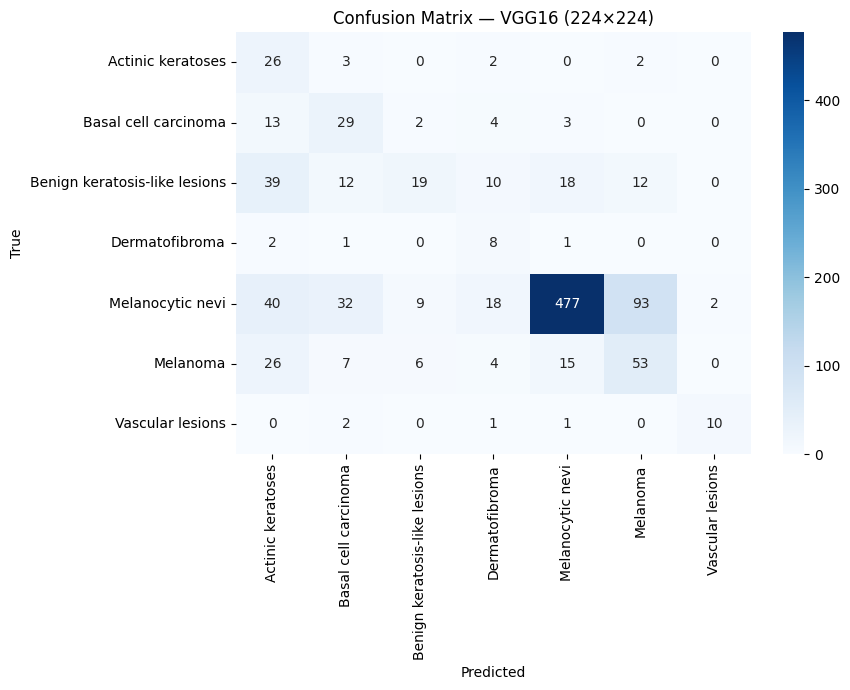

In [26]:
# Report
print("\nClassification report (VGG16):")
print(classification_report(y_true, y_pred, target_names=names, digits=3))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(idx_to_class))))
plt.figure(figsize=(9,7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=names, yticklabels=names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix — VGG16 (224×224)")
plt.tight_layout(); plt.show()